In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/credit_card_fraud_dataset.csv")

In [3]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [4]:
df.shape

(100000, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [6]:
df.isnull().sum()

TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include="number")

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [25]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["TransactionDate"] = df["TransactionDate"].dt.normalize()

df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month_name()
df["Year_Month"] = df["TransactionDate"].dt.strftime("%Y-%m")

In [18]:
transaction_count = df["TransactionType"].value_counts()
transaction_count

TransactionType
refund      50131
purchase    49869
Name: count, dtype: int64

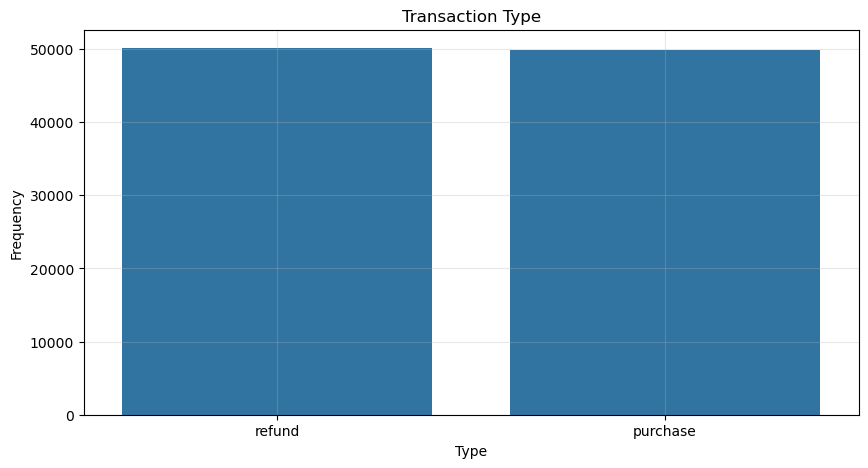

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(x=transaction_count.index, y=transaction_count.values)
plt.title("Transaction Type")
plt.xlabel("Type")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
location_count = df["Location"].value_counts()
location_count

Location
Chicago         10193
San Diego       10111
Dallas          10076
San Antonio     10062
New York         9993
Houston          9991
Phoenix          9960
Los Angeles      9936
Philadelphia     9873
San Jose         9805
Name: count, dtype: int64

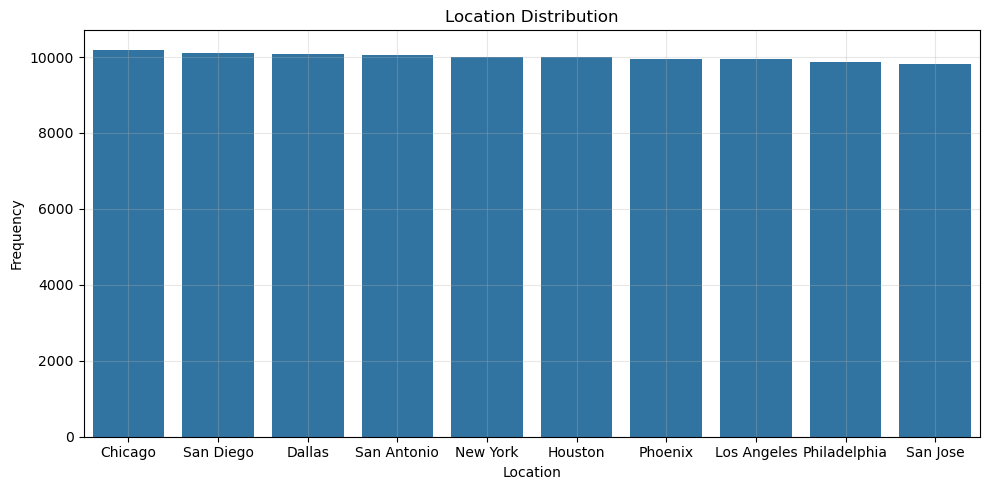

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x=location_count.index, y=location_count.values)
plt.title("Location Distribution")
plt.xlabel("Location")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
fraud_count = df["IsFraud"].value_counts()
fraud_count

IsFraud
0    99000
1     1000
Name: count, dtype: int64

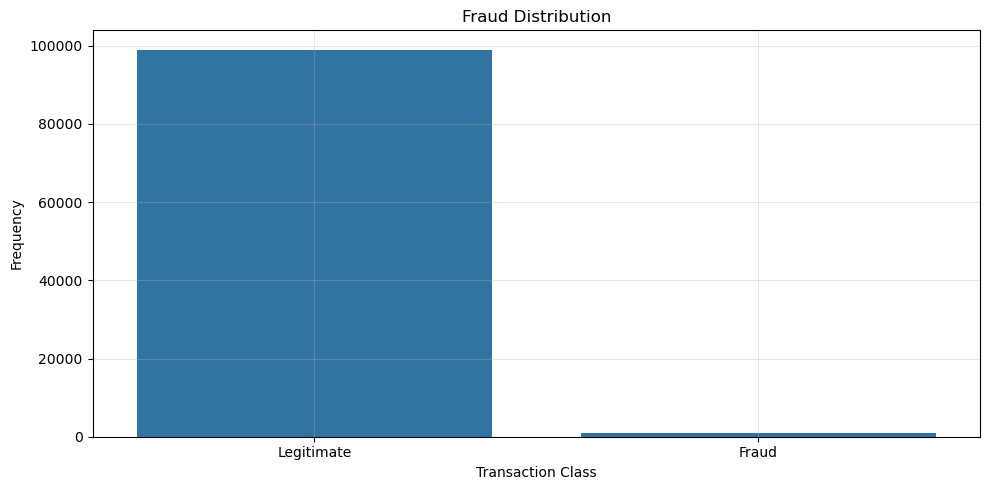

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x=fraud_count.index, y=fraud_count.values)
plt.title("Fraud Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Frequency")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
df["Year"].value_counts()

Year
2024    80449
2023    19551
Name: count, dtype: int64

In [36]:
year_month_df = df.groupby("Year_Month")["Amount"].sum().reset_index()
year_month_df.head()

,Year_Month,Amount
0,2023-10,7102476.03
1,2023-11,20022542.05
2,2023-12,21457597.69
3,2024-01,20895021.39
4,2024-02,19672678.12


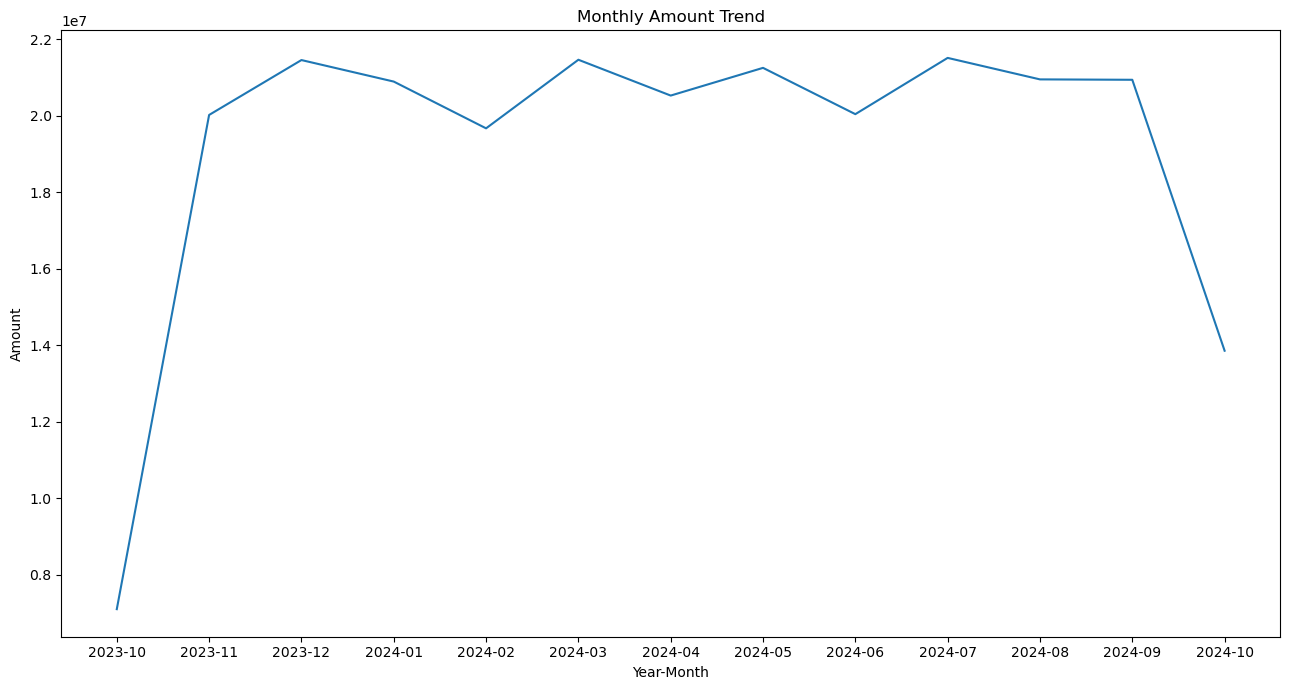

In [38]:
plt.figure(figsize=(13, 7))
sns.lineplot(x="Year_Month", y="Amount", data=year_month_df)
plt.title("Monthly Amount Trend")
plt.xlabel("Year-Month")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()